In [6]:
import pandas as pd
import numpy as np

## Plot and summary for Branching and Single Federated

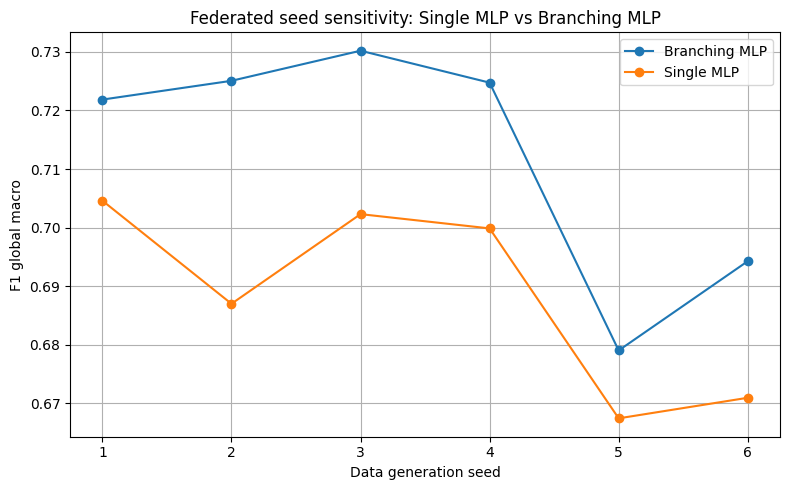

                   mean       std       min       max
model                                                
Branching MLP  0.712523  0.020813  0.678991  0.730214
Single MLP     0.688664  0.016340  0.667391  0.704584

Paired comparison:
   data_seed  f1_global_macro_single  f1_global_macro_branching  \
0          1                0.704584                   0.721863   
1          2                0.686969                   0.725072   
2          3                0.702287                   0.730214   
3          4                0.699849                   0.724756   
4          5                0.667391                   0.678991   
5          6                0.670905                   0.694242   

   difference_branching_minus_single  
0                           0.017279  
1                           0.038103  
2                           0.027927  
3                           0.024907  
4                           0.011600  
5                           0.023338  

Mean difference:
0.0

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Paths
single_path = r"C:\Users\oskar\OneDrive\Desktop\Seed_test\federated_seed_sensitivity_summary_64_128_64.csv"
branching_path = r"C:\Users\oskar\OneDrive\Desktop\Seed_test\federated_seed_sensitivity_summary_heads.csv"

# Read data
single_df = pd.read_csv(single_path)
branch_df = pd.read_csv(branching_path)

# Add model labels
single_df["model"] = "Single MLP"
branch_df["model"] = "Branching MLP"

# Combine
df = pd.concat([single_df, branch_df], ignore_index=True)

# Plot
plt.figure(figsize=(8, 5))

for model_name, model_df in df.groupby("model"):
    plt.plot(
        model_df["data_seed"],
        model_df["f1_global_macro"],
        marker="o",
        label=model_name
    )

plt.xlabel("Data generation seed")
plt.ylabel("F1 global macro")
plt.title("Federated seed sensitivity: Single MLP vs Branching MLP")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(r"C:\Users\oskar\OneDrive\Desktop\Seed_test\federated_branching_vs_single.png", dpi=300)
plt.show()

# Summary
summary = df.groupby("model")["f1_global_macro"].agg(["mean", "std", "min", "max"])
print(summary)

# Paired difference
merged = single_df[["data_seed", "f1_global_macro"]].merge(
    branch_df[["data_seed", "f1_global_macro"]],
    on="data_seed",
    suffixes=("_single", "_branching")
)

merged["difference_branching_minus_single"] = (
    merged["f1_global_macro_branching"] - merged["f1_global_macro_single"]
)

print("\nPaired comparison:")
print(merged)

print("\nMean difference:")
print(merged["difference_branching_minus_single"].mean())

print("\nBranching wins:")
print((merged["difference_branching_minus_single"] > 0).sum(), "/", len(merged))

## Final plot for Single, Branching and Four (Federated)

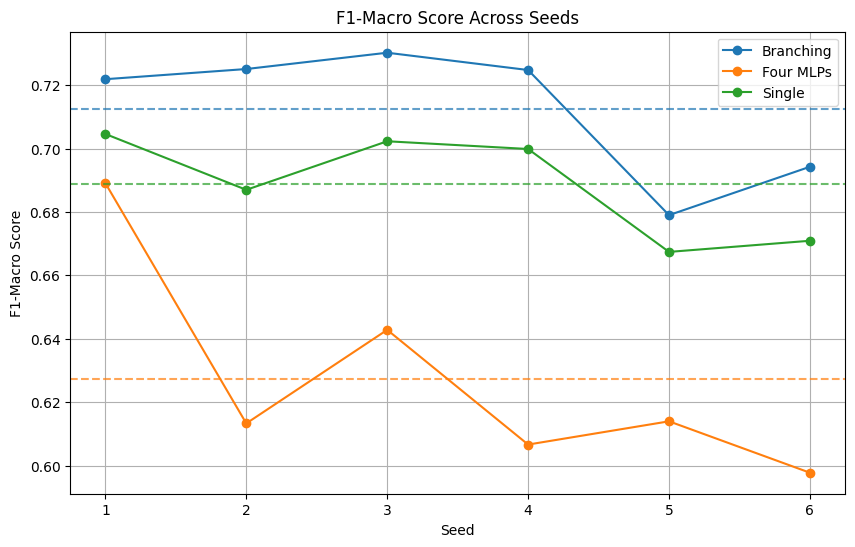

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# ===== HARDCODED IMPORTS =====
df_6412864 = pd.read_csv(r"C:\Users\oskar\OneDrive\Desktop\Seed_test\federated_seed_sensitivity_summary_64_128_64.csv")
df_four = pd.read_csv(r"C:\Users\oskar\OneDrive\Desktop\Seed_test\federated_seed_sensitivity_summary_four.csv")
df_heads = pd.read_csv(r"C:\Users\oskar\OneDrive\Desktop\Seed_test\federated_seed_sensitivity_summary_heads.csv")

# ===== ADD MODEL NAMES =====
df_6412864["Architecture"] = "Single"
df_four["Architecture"] = "Four MLPs"
df_heads["Architecture"] = "Branching"

# ===== COMBINE =====
df = pd.concat([
    df_6412864,
    df_four,
    df_heads
])

# ===== PLOT =====
plt.figure(figsize=(10,6))

for architecture, group in df.groupby("Architecture"):

    group = group.sort_values("data_seed")

    # Plot main line and save color
    line, = plt.plot(
        group["data_seed"],
        group["f1_global_macro"],
        marker="o",
        label=architecture
    )

    # Use SAME color for average line
    avg = group["f1_global_macro"].mean()

    plt.axhline(
        y=avg,
        linestyle="--",
        alpha=0.7,
        color=line.get_color()
    )

# ===== LABELS =====
plt.xlabel("Seed")
plt.ylabel("F1-Macro Score")
plt.title("F1-Macro Score Across Seeds")
plt.grid(True)
plt.legend()

plt.show()

## Centralized single, branching and four:

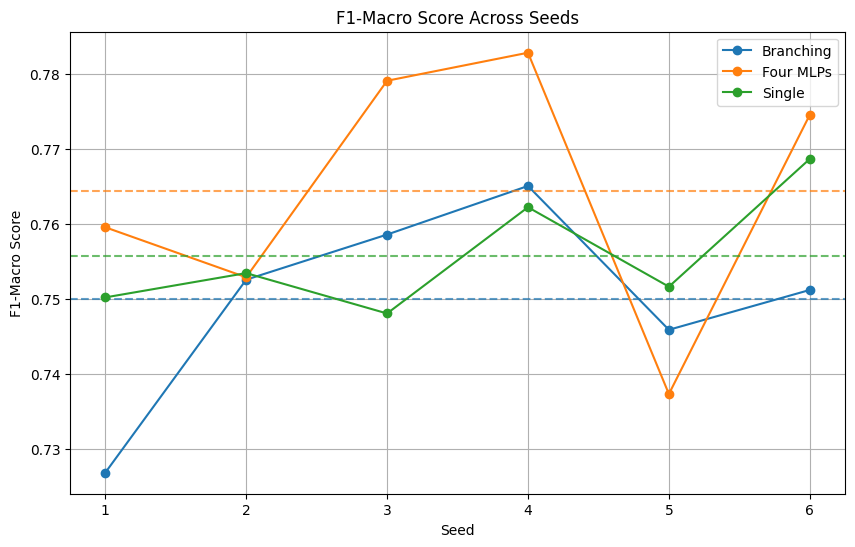

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# ===== HARDCODED IMPORTS =====
df_6412864 = pd.read_csv(r"C:\Users\oskar\OneDrive\Desktop\4 Semester\Dataproject\Federated-dental-risk-vol2\federated-dental-risk-prediction\src\fdrp\analysis\Branching Tests\centralized_seed_sensitivity_summary_64_128_64.csv")
df_four = pd.read_csv(r"C:\Users\oskar\OneDrive\Desktop\4 Semester\Dataproject\Federated-dental-risk-vol2\federated-dental-risk-prediction\src\fdrp\analysis\Branching Tests\centralized_seed_sensitivity_summary_four.csv")
df_heads = pd.read_csv(r"C:\Users\oskar\OneDrive\Desktop\4 Semester\Dataproject\Federated-dental-risk-vol2\federated-dental-risk-prediction\src\fdrp\analysis\Branching Tests\Centralized_seed_sensitivity_summary_heads.csv")



# ===== ADD MODEL NAMES =====
df_6412864["Architecture"] = "Single"
df_four["Architecture"] = "Four MLPs"
df_heads["Architecture"] = "Branching"

# ===== COMBINE =====
df = pd.concat([
    df_6412864,
    df_four,
    df_heads
])

# ===== PLOT =====
plt.figure(figsize=(10,6))

for architecture, group in df.groupby("Architecture"):

    group = group.sort_values("data_seed")

    # Plot main line and save color
    line, = plt.plot(
        group["data_seed"],
        group["f1_global_macro"],
        marker="o",
        label=architecture
    )

    # Use SAME color for average line
    avg = group["f1_global_macro"].mean()

    plt.axhline(
        y=avg,
        linestyle="--",
        alpha=0.7,
        color=line.get_color()
    )

# ===== LABELS =====
plt.xlabel("Seed")
plt.ylabel("F1-Macro Score")
plt.title("F1-Macro Score Across Seeds")
plt.grid(True)
plt.legend()

plt.show()